[![preview notebook](https://img.shields.io/static/v1?label=render%20on&logo=github&color=87ce3e&message=GitHub)](https://github.com/open-atmos/PySDM/blob/main/examples/PySDM_examples/Kulmala_et_al_1997/fig_1.ipynb)
[![launch on mybinder.org](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/open-atmos/PySDM.git/main?urlpath=lab/tree/examples/PySDM_examples/Kulmala_et_al_1997/fig_1.ipynb)
[![launch on Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/open-atmos/PySDM/blob/main/examples/PySDM_examples/Kulmala_et_al_1997/fig_1.ipynb)

#### based on Fig. 1 from Kulmala et al. 1997 (Nature 388)  "_Clouds without supersaturation_"
https://doi.org/10.1038/41000

In [ ]:
import os, sys
os.environ['NUMBA_THREADING_LAYER'] = 'workqueue'  # PySDM & PyMPDATA don't work with TBB; OpenMP has extra dependencies on macOS
if 'google.colab' in sys.modules:
    !pip --quiet install open-atmos-jupyter-utils
    from open_atmos_jupyter_utils import pip_install_on_colab
    pip_install_on_colab('PySDM-examples', 'PySDM')

In [64]:
from open_atmos_jupyter_utils import show_plot
from PySDM import Formulae
from PySDM.physics import si, in_unit
import mendeleev
import numpy as np
from matplotlib import pyplot

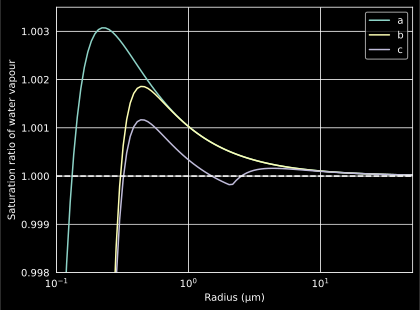

In [94]:
formulae = Formulae(hygroscopicity='KappaKoehlerLeadingTerms')
const = formulae.constants

radii = np.logspace(-.95, 1.7, 100) * si.um

# values from the paper:
T = 298 * si.K
rd3 = (30 * si.nm)**3
r0 = 500 * si.nm
M_ws = ( # molar mass of CaSO4
    1 * mendeleev.Ca.atomic_weight * si.g / si.mol +
    1 * mendeleev.S.atomic_weight * si.g / si.mol +
    4 * mendeleev.O.atomic_weight * si.g / si.mol
)
S_ws = 0.00209 * si.g / si.cm**3 # solubility

# not in the paper! (and not realistic)
kappa=.666
rho_ws = .4 * si.g / si.cm**3
# TODO: instead, we should likely use the kappa formula 4a-c from Sullivan et al. 2009
# (https://doi.org/10.5194/acp-9-3303-2009)

curve_a = formulae.hygroscopicity.RH_eq(
    radii,
    T=T,
    kp=kappa,
    rd3=rd3,
    sgm=const.sgm_w,
)

# approximated with a single leading term
curve_b = curve_a - kp * rd3 / radii**6 * r0**3

# x_solute = 1 / (1 + n_water / n_solute)
x_ws = lambda r: 1 / (1 + M_ws / const.Mv * np.maximum(rho_ws / S_ws, (r/r0)**3 * const.rho_w / rho_ws))
curve_c = curve_b - x_ws(radii)

pyplot.plot(in_unit(radii, si.um), curve_a, label='a')
pyplot.plot(in_unit(radii, si.um), curve_b, label='b')
pyplot.plot(in_unit(radii, si.um), curve_c, label='c')
pyplot.axhline(1, ls='--')
pyplot.xscale('log')
pyplot.gca().set(
    xlabel='Radius (μm)',
    ylabel='Saturation ratio of water vapour',
    xlim=(1e-1, 5e1),
    ylim=(.998, 1.0035),
)
pyplot.legend()
show_plot('fig_1')